[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kevisback/bda-course/blob/main/wise2627/notebooks/01_geschichte_und_use_cases.ipynb)

*Präsentations-Notebook für Sitzung 1 — als Diashow starten (Ansicht → Diashow starten) oder durchscrollen.*

# Von Big Data zu KI
### Sitzung 1 — Wofür KI gut ist: Geschichte & Anwendungsfälle

**Big Data Analytics (W3-BDA) · HTW Berlin · Master WI**

## Ziel der Vorlesung: Aufbau eines KI-basierten Produkts "Review Radar"

- Aus hunderten unstrukturierten Bewertungen wird ein klares Bild: Sentiment, Themen, Trends, Zusammenfassung.

### So sieht der Review Radar aus (Mock)

In [ ]:
# ============================================================
#  REVIEW RADAR — Hook-Demo (Sitzung 1)
#  Alles in einer Zelle: Daten erzeugen -> analysieren -> Dashboard.
#  Laeuft OHNE Schluessel (Mock). Einfach ausfuehren und nach unten scrollen.
# ============================================================
import random, re
from collections import Counter, defaultdict
from datetime import date, timedelta
from IPython.display import HTML, display

# --- 1. Synthetischer Bewertungs-Korpus (fiktives Produkt "Nimbus Q2") -------
SEED = 42
POS = ["der Klang ist hervorragend","satte Baesse","die Geraeuschunterdrueckung ist top",
       "der Akku haelt den ganzen Tag","sitzt super bequem","Bluetooth verbindet sofort",
       "top verarbeitet","klasse fuer den Preis","die App ist uebersichtlich"]
NEG = ["die App stuerzt staendig ab","der rechte Ohrhoerer laedt nicht mehr",
       "die Geraeuschunterdrueckung rauscht","viel zu teuer","das Case wirkt billig",
       "der Akku ist nach einer Stunde leer","die Verbindung bricht ab","der Bass ist matschig"]
POS_OP = ["Bin begeistert:","Wirklich gut:","Top Kauf.","Sehr zufrieden:","Klare Sache:","Ich liebe sie:"]
NEG_OP = ["Enttaeuschend:","Leider schlecht:","Finger weg -","Nie wieder:","Aergerlich:","Bin frustriert:"]

def _mk(rng):
    r = rng.random()
    if r < 0.45:
        return f"{rng.choice(POS_OP)} {rng.choice(POS)}.", "positive"
    if r < 0.80:
        return f"{rng.choice(NEG_OP)} {rng.choice(NEG)}.", "negative"
    p, n = rng.choice(POS), rng.choice(NEG)
    return f"{p[0].upper()+p[1:]}, aber {n}.", "mixed"

def generate(n=300):
    rng = random.Random(SEED); start = date(2026,1,1); rows=[]
    for i in range(n):
        text, truth = _mk(rng)
        day = int(rng.triangular(0,270, 200 if truth=="negative" else 90))
        rows.append({"date": (start+timedelta(days=day)).isoformat(), "text": text})
    return rows

# --- 2. Analyse (Mock-Klassifikation, key-frei) ------------------------------
def classify(t):
    t=t.lower()
    pos=sum(w in t for w in ["gut","top","hervorragend","bequem","liebe","begeistert","klasse","zufrieden","satte"])
    neg=sum(w in t for w in ["schlecht","teuer","stuerzt","rauscht","billig","leer","bricht","matschig","finger weg","enttaeuscht","aergerlich","frustriert","nie wieder","laedt nicht"])
    if pos and neg: return "mixed"
    if pos: return "positive"
    if neg: return "negative"
    return "neutral"

THEMEN={"Klang":["klang","baesse","bass","sound"],"Akku":["akku","laden","laedt","leer"],
        "App":["app"],"Geraeuschunterdrueckung":["geraeusch","rauscht"],"Verbindung":["bluetooth","verbindung","bricht"],
        "Komfort":["bequem","sitzt"],"Preis":["preis","teuer"],"Verarbeitung":["verarbeitet","case","billig"]}
def themen(t):
    t=t.lower(); return [k for k,ws in THEMEN.items() if any(w in t for w in ws)]

daten=[{**r,"sentiment":classify(r["text"]),"themen":themen(r["text"])} for r in generate(300)]

# --- 3. Aggregieren ----------------------------------------------------------
n=len(daten)
sent=Counter(d["sentiment"] for d in daten)
lob=Counter(); kritik=Counter()
for d in daten:
    for th in d["themen"]:
        if d["sentiment"]=="positive": lob[th]+=1
        if d["sentiment"]=="negative": kritik[th]+=1
by_month=defaultdict(lambda:Counter())
for d in daten: by_month[d["date"][:7]][d["sentiment"]]+=1
def pc(x): return round(100*sent.get(x,0)/n)
pos,neg,mix,neu=pc("positive"),pc("negative"),pc("mixed"),pc("neutral")
top_lob=lob.most_common(3); top_kritik=kritik.most_common(3)

# --- 4. Dashboard (dark, shadcn-inspired, zentriert) ------------------------
from IPython.display import HTML, display
C_POS,C_MIX,C_NEU,C_NEG="#22c55e","#f59e0b","#64748b","#ef4444"

# SVG-Trendchart (passt in die Karte, volle Breite)
monate=sorted(by_month)
p=[by_month[m].get("positive",0) for m in monate]
ng=[by_month[m].get("negative",0) for m in monate]
W,H=740,180; padL,padR,padT,padB=36,12,14,40; maxv=max(max(p),max(ng),1)
def X(i): return padL+i*(W-padL-padR)/max(len(monate)-1,1)
def Y(v): return padT+(H-padT-padB)*(1-v/maxv)
def poly(vals): return " ".join(f"{X(i):.1f},{Y(v):.1f}" for i,v in enumerate(vals))
def dots(vals,c): return "".join(f"<circle cx='{X(i):.1f}' cy='{Y(v):.1f}' r='3.5' fill='{c}'/>" for i,v in enumerate(vals))
grid=""
for gv in [0,maxv//2,maxv]:
    yy=Y(gv)
    grid+=f"<line x1='{padL}' y1='{yy:.1f}' x2='{W-padR}' y2='{yy:.1f}' stroke='#334155' stroke-width='1'/>"
    grid+=f"<text x='{padL-6}' y='{yy+3:.1f}' text-anchor='end' font-size='9' fill='#64748b'>{gv}</text>"
xlabels="".join(f"<text x='{X(i):.1f}' y='{H-padB+16:.1f}' text-anchor='middle' font-size='8.5' fill='#64748b'>{m[5:]}</text>" for i,m in enumerate(monate))
svg=f'<svg viewBox="0 0 {W} {H}" width="100%" style="display:block" xmlns="http://www.w3.org/2000/svg">{grid}<polyline points="{poly(p)}" fill="none" stroke="{C_POS}" stroke-width="2.5"/><polyline points="{poly(ng)}" fill="none" stroke="{C_NEG}" stroke-width="2.5"/>{dots(p,C_POS)}{dots(ng,C_NEG)}{xlabels}</svg>'

card="background:#1e293b;border:1px solid #334155;border-radius:14px;box-shadow:0 1px 3px rgba(0,0,0,.3)"
def trows(items): return "".join(f"<li style='display:flex;justify-content:space-between;align-items:center;padding:7px 0;border-bottom:1px solid #334155'><span style='color:#cbd5e1'>{t}</span><span style='font-weight:600;color:#f1f5f9;background:#0f172a;border-radius:6px;padding:1px 8px;font-size:13px'>{c}</span></li>" for t,c in items)
def dot(c): return f"<span style='display:inline-block;width:9px;height:9px;border-radius:50%;background:{c};margin-right:6px;vertical-align:middle'></span>"

html=f"""
<div style="font-family:ui-sans-serif,-apple-system,Segoe UI,Roboto,sans-serif;max-width:820px;margin:0 auto;background:#0f172a;padding:20px;border-radius:18px">
  <div style="display:flex;justify-content:space-between;align-items:center;margin:2px 4px 16px">
    <div><div style="font-size:20px;font-weight:800;color:#f8fafc">Review Radar</div>
      <div style="font-size:13px;color:#94a3b8">Nimbus Q2 &middot; {n} Bewertungen analysiert</div></div>
    <span style="font-size:11px;font-weight:600;color:#4ade80;background:#052e16;border:1px solid #166534;border-radius:999px;padding:4px 12px">LIVE</span>
  </div>
  <div style="{card};padding:18px 20px;margin-bottom:16px">
    <div style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.5px;color:#64748b;margin-bottom:12px">Gesamtstimmung auf einen Blick</div>
    <div style="display:flex;height:30px;border-radius:8px;overflow:hidden;margin-bottom:12px">
      <div style="width:{pos}%;background:{C_POS}"></div><div style="width:{mix}%;background:{C_MIX}"></div>
      <div style="width:{neu}%;background:{C_NEU}"></div><div style="width:{neg}%;background:{C_NEG}"></div></div>
    <div style="display:flex;gap:20px;font-size:13px;color:#94a3b8">
      <span>{dot(C_POS)}Positiv <b style="color:#f1f5f9">{pos}%</b></span><span>{dot(C_MIX)}Gemischt <b style="color:#f1f5f9">{mix}%</b></span>
      <span>{dot(C_NEU)}Neutral <b style="color:#f1f5f9">{neu}%</b></span><span>{dot(C_NEG)}Negativ <b style="color:#f1f5f9">{neg}%</b></span></div>
  </div>
  <div style="display:flex;gap:16px;margin-bottom:16px">
    <div style="{card};flex:1;padding:18px 20px">
      <div style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.5px;color:#4ade80;margin-bottom:10px">Top-Lob</div>
      <ul style="list-style:none;margin:0;padding:0;font-size:15px">{trows(top_lob)}</ul></div>
    <div style="{card};flex:1;padding:18px 20px">
      <div style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.5px;color:#f87171;margin-bottom:10px">Top-Kritik</div>
      <ul style="list-style:none;margin:0;padding:0;font-size:15px">{trows(top_kritik)}</ul></div>
  </div>
  <div style="{card};padding:18px 20px">
    <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:10px">
      <div style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.5px;color:#64748b">Entwicklung ueber die Zeit</div>
      <div style="font-size:12px;color:#94a3b8">{dot(C_POS)}Positiv &nbsp; {dot(C_NEG)}Negativ</div></div>
    {svg}
    <div style="font-size:11px;color:#64748b;margin-top:4px">Anzahl Bewertungen pro Monat</div>
  </div>
</div>
"""
display(HTML(html))

### Im Laufe des Semesters entwickeln wir das Produkt

*„Das baut ihr — nicht zuschauen, sondern selbst. Und in der zweiten Hälfte lernt ihr, den Moment zu erkennen, in dem es euch selbstbewusst anlügt.“*

> 💡 **Merkt euch das Bild** — dahin arbeiten wir das ganze Semester.

## Ablauf heute

Ihr habt gerade das Ziel gesehen. So läuft der heutige Abend:

1. ✅ **Der Hook** — das fertige Werkzeug *(gerade gesehen)*
2. **Zur Person** — wer euch unterrichtet
3. **Kurs & Prüfung** — Ziele, Ablauf, Prüfungsrelevantes
4. **Organisatorisches** — Termine, GitHub/Colab, was ihr braucht
5. *— kurze Pause —*
6. **Inhalt: Von Big Data zu KI** — Geschichte, Anwendungsfälle, Grenzen
7. **Setup-Check** — alle öffnen einmal das Repo in Colab
8. **Ausblick**

> 💡 **Kernpunkt:** ~50 % Konzept, ~50 % selbst bauen. Kein Vorwissen nötig.

## Zur Person

> ✏️ *Platzhalter — mit eigenen Angaben füllen:*

- **[Name / Rolle]** — z. B. baut LLM-basierte Systeme in der Praxis
- **[Hintergrund]** — was dich qualifiziert, das zu unterrichten
- **[Bezug zum Kurs]** — warum genau dieses Thema, aus echter Erfahrung
- *(Optional: eine kurze Anekdote — ein KI-System, das überraschend gescheitert ist. Passt zum Kurs-Thema „wo KI versagt“.)*

> 💡 **Botschaft an den Raum:** Praktiker, kein Lehrbuch — wir bauen, was in Unternehmen wirklich läuft.

## Kurs & Prüfung

**Der Kurs:** wir bauen *ein* KI-Produkt über das ganze Semester — Schritt für Schritt, an einem durchgehenden Fall. Erste Hälfte: bauen. Zweite Hälfte: lernen, dem Ergebnis zu misstrauen und es zu prüfen.

**Ziele:** ihr könnt danach (1) ein LLM-gestütztes Analyse-Werkzeug bauen und (2) beurteilen, wann man ihm trauen darf. ~50/50.

**Prüfungsleistung:** Projektarbeit — ein **Konzept** + eine funktionierende **Demo**. Ihr wendet das Werkzeug auf eine eigene Domäne an (Support-Anfragen, Social Media, Umfragen …). Gruppen von 2–3 möglich.

> 💡 **Prüfungsrelevant:** alles baut auf das Projekt hin. Das im Kurs gebaute Werkzeug ist eure Vorlage. Details folgen im schriftlichen Prüfungs-Briefing.

## Organisatorisches

- **Termine:** wöchentlich mittwochs, 17:15–19:45 Uhr
- **Format:** Präsenz (Okt–Dez, Ende Jan/Feb); **drei Online-Sitzungen im Januar**
- **Weihnachtspause:** 23.12. & 30.12.
- **Werkzeuge:** alles im Browser über **Google Colab** — keine Installation. Ihr braucht nur einen Laptop und ein **kostenloses Google-Konto**.
- **Materialien:** alle Notebooks offen auf **GitHub**, pro Sitzung ergänzt.

> 💡 **Kein Programmier-Vorwissen nötig** — wir fangen bei null an.

## — Kurze Pause —

Danach: der inhaltliche Teil. Wie sind wir von „Big Data“ zu KI gekommen, und wo funktioniert das wirklich?

## Teil A — Von „Big Data“ zu KI

Der Kurs heißt **Big Data Analytics** — und wir machen „irgendwas mit KI“. Kein Widerspruch: dieselbe Disziplin, neue Werkzeuge.

> *Roter Faden: mit jedem Schritt gibt der Mensch **weniger explizit vor** — die Maschine leitet mehr selbst aus Daten ab.*

## 0. Was „Big Data Analytics“ klassisch bedeutet

Bevor „KI“ das Schlagwort war, meinte *Big Data Analytics* eine handfeste Menge an Konzepten — bis heute das Fundament:

- **Statistik** — Mittelwerte, Verteilungen, Korrelationen
- **Machine Learning** — Modelle, die aus Daten Muster lernen
- **Die „3 Vs“** — *Volume*, *Velocity*, *Variety*
- **Infrastruktur** — Data Warehouses, verteilte Verarbeitung (Hadoop, Spark)
- **Visualisierung & Dashboards** — aus Analyse eine Entscheidungsgrundlage

> 💡 **Kernpunkt:** „Big Data Analytics“ heißt im Kern **aus großen Datenmengen Entscheidungen ableiten**. Das Ziel ändert sich nie — nur die Werkzeuge.

> ⚠️ **FAKT PRÜFEN:** „3 Vs“ (Doug Laney, ~2001), Hadoop/Spark — Namen/Jahre gegenprüfen.

## 1. Die alte Welt: Regeln von Hand

Die ersten Jahrzehnte „KI“ waren **regelbasiert**: Menschen schrieben explizit auf, was das System tun soll. *Wenn X und Y, dann Z.*

Das funktioniert — solange die Welt sich an die Regeln hält:
- Für jede Ausnahme braucht es eine neue Regel
- Sprache, Bilder, echtes Chaos lassen sich nicht in Regeln fassen
- Wer schreibt die Regel für „erkenne eine Katze auf einem Foto“?

> 💡 **Kernpunkt:** Regeln skalieren nicht auf die Unordnung der echten Welt.

> ⚠️ **FAKT PRÜFEN:** „Expertensysteme der 1980er“ (MYCIN, DENDRAL) — bei Beispiel gegenprüfen.

## 2. Der Wechsel: aus Daten lernen

Die Idee des **maschinellen Lernens** — das Herz der klassischen Big-Data-Ära: statt die Regel vorzugeben, zeigt man dem System **viele Beispiele** und lässt es die Regel selbst finden.

> Nicht: „So sieht Spam aus“ (Regel).
> Sondern: „Hier sind 10.000 markierte E-Mails — finde selbst heraus, was sie unterscheidet.“

Die Arbeit verschiebt sich zum **Daten-Sammeln und -Labeln**. Hier wurde „big data“ wichtig: mehr (gute) Daten = bessere Modelle.

> 💡 **Kernpunkt:** Der Mensch liefert Beispiele und ein Ziel; das Muster findet die Maschine.

## 3. Der Deep-Learning-Moment

Neuronale Netze gibt es theoretisch seit Jahrzehnten. Praktisch nützlich wurden sie erst, als **drei Dinge zusammenkamen** — alle drei „big-data“-Themen:

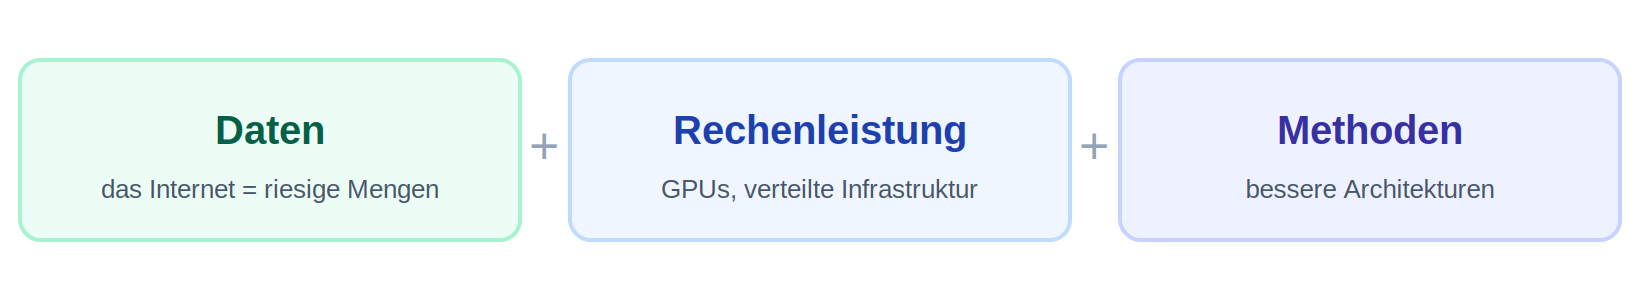

Ab da lösten Modelle Aufgaben, die vorher „unmöglich für Computer“ waren: Bilderkennung, Spracherkennung, Übersetzung — auf einmal *brauchbar*.

> 💡 **Kernpunkt:** Nicht eine geniale Idee, sondern Daten + Rechenleistung + Methode *zusammen*.

> ⚠️ **FAKT PRÜFEN:** ImageNet-/AlexNet-Durchbruch (2012) — Jahr und Namen verifizieren.

## 4. Der LLM-Sprung: warum sich 2022+ anders anfühlte

Große Sprachmodelle (**LLMs**) sind auf riesigen Textmengen trainiert. Das Neue war **wie allgemein** sie wurden: dasselbe Modell übersetzt, fasst zusammen, klassifiziert, schreibt Code.

Der entscheidende Schritt für uns: **Big Data Analytics wurde auf unstrukturierten Text anwendbar.** Klassisch brauchte man Zahlen in Tabellen. LLMs machen aus Fließtext — Bewertungen, Tickets, Posts — verwertbare Struktur.

Dazu: **man muss kein KI-Spezialist mehr sein.** Aufgabe in Sprache beschreiben (ein *Prompt*) → Ergebnis.

> 💡 **Kernpunkt:** LLMs machten KI zu einem allgemeinen, per Sprache gesteuerten Werkzeug — und öffneten BDA für freien Text.

> ⚠️ **FAKT PRÜFEN:** ChatGPT (Ende 2022); „Transformer“-Paper (2017) — Daten prüfen.

## Der Bogen: klassische → moderne Big Data Analytics

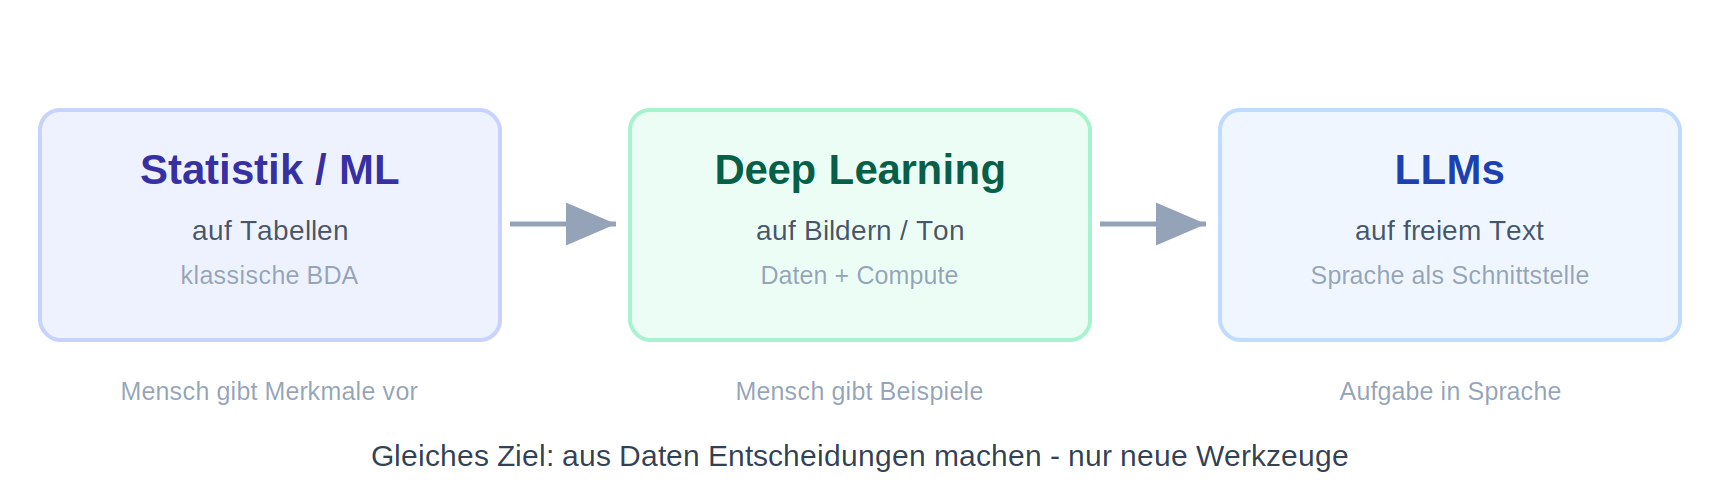

> 💡 **Kernpunkt:** Dieser Kurs ist moderne Big Data Analytics — dasselbe Ziel, neue Mittel (LLMs auf Text).

## Teil B — Wo funktioniert das wirklich?

Der ehrliche Teil. KI ist echt nützlich **und** wird massiv überverkauft — beides gleichzeitig. Eure wertvollste Fähigkeit ist nicht „KI bauen“, sondern **beurteilen, wann sie taugt**.

### 1. Wo es echt funktioniert

- **Sprache in Struktur bringen** — klassifizieren, zusammenfassen, übersetzen *(unser Kurs)*
- **Muster in großen Datenmengen** — Betrug, Empfehlungen, Prognosen *(klassische BDA)*
- **Wahrnehmung** — Bild- und Spracherkennung
- **Assistenz** — Entwürfe, Code, Boilerplate

Gemeinsam: **großes Volumen** + **Fehlertoleranz**.

> 💡 **Kernpunkt:** KI glänzt bei Volumen + Fehlertoleranz.

### 2. Das gemeinsame Muster

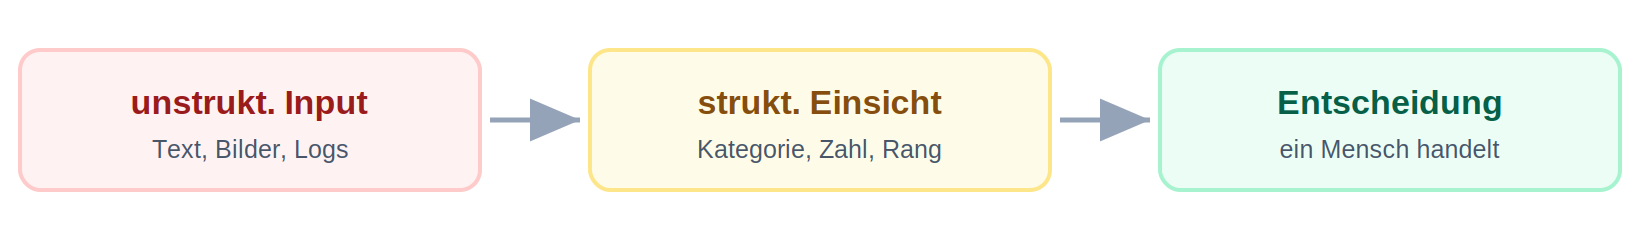

Das ist **genau unser Produkt** (Bewertungen → Sentiment/Themen → „was verbessern wir?“). Übertragbar: Support-Tickets, Umfragen, Social Media — dasselbe Muster, andere Quelle.

> 💡 **Kernpunkt:** Ein Muster, viele Anwendungsfälle. Einmal verstanden, überall anwendbar.

### 3. Wo es scheitert — und das ist wichtiger

- **Selbstbewusst falsch** — plausible, aber falsche Antwort; ohne Prüfung merkt es niemand
- **Verzerrte Daten** — schiefe Daten → das Modell reproduziert und skaliert die Schieflage
- **Kein echtes Verständnis** — erkennt Muster, „versteht“ nichts; bricht bei Ungewohntem ein
- **Der Hype-Aufschlag** — vieles „KI“-Etikettierte ist simpel oder funktioniert nicht

> 💡 **Kernpunkt:** Nicht „kann KI das?“, sondern: **woher weiß ich, ob das Ergebnis stimmt — und was kostet ein Fehler?**

> ⚠️ **FAKT PRÜFEN:** Bei konkretem Fehlschlag-Beispiel einen gut dokumentierten Fall verifizieren, statt aus dem Gedächtnis erzählen.

### 4. Die ehrliche Mitte

KI ist weder Magie noch Schwindel — ein **Werkzeug mit einem Job**: großes Textvolumen bewältigen, das kein Mensch durchliest — solange man weiß, wo es lügt, und einen Menschen an den richtigen Stellen einbaut.

Diese Haltung — nützlich *und* skeptisch — zieht sich durch den Kurs.

## Der tiefere Punkt: „Eine Aufgabe ist eine Entscheidung“

Wenn wir sagen „ordne die Bewertung als **positiv / negativ / neutral** ein“, klingt das objektiv. Ist es nicht — es ist eine **Entscheidung, die wir treffen**:

- Ist „okay, tut was es soll“ positiv oder neutral?
- Lob *und* Kritik zugleich — positiv, negativ, „gemischt“?
- Ist Sarkasmus („super, schon kaputt“) positiv, weil „super“ drinsteht?

Es gibt keine Kategorie „da draußen“, die wir nur ablesen. **Wir erfinden die Kategorien** — und damit auch, was später „richtig“ heißt.

> 💡 **Kernpunkt:** Bevor man misst, ob ein Modell richtig liegt, muss man entscheiden, was „richtig“ überhaupt bedeuten soll. *(Roter Faden der 2. Hälfte.)*

## Ausblick & Setup-Check

**Warum Produktbewertungen?** Messiger echter Text, echter Geschäftswert, und jeder Fehlermodus taucht auf (Sarkasmus, Fakes, gemischte Meinungen).

**Jetzt — Setup-Check:** alle öffnen einmal das Repo in Colab und führen eine Zelle aus. Damit nächste Woche nicht mit 20 kaputten Laptops beginnt.

**Nächste Woche (14.10):** das erste echte Stück Code — ein LLM ordnet die erste Bewertung ein.

> 💡 Das im Kurs gebaute Werkzeug ist eure Prüfungs-Vorlage. Ab jetzt bauen wir es.